# 👔 Advanced HR Attrition Analysis

Welcome to the enhanced HR Attrition Analysis. This notebook investigates the key drivers of employee turnover.
We have transitioned from basic visualizations to **problem-solution based insights** and upgraded our predictive capabilities using a **Random Forest Model**.

## 📊 Key Performance Indicators & Setup
Let's begin by importing our libraries, setting up a modern visualization theme, and loading our data.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Set a stylish modern theme for all seaborn plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 120})

# Load Data
df = pd.read_csv("EmployeeAttrition.csv")
print(f"Total Employees: {len(df)}")
print(f"Total Features: {len(df.columns)}")

Total Employees: 1470
Total Features: 32


## 🧹 Data Cleaning
We remove columns that offer no variance or are not useful for predicting attrition.

In [17]:
if 'Over18' in df.columns:
    df.drop('Over18', axis=1, inplace=True)
if 'EmployeeCount' in df.columns:
    df.drop('EmployeeCount', axis=1, inplace=True)
if 'StandardHours' in df.columns:
    df.drop('StandardHours', axis=1, inplace=True)

# Standardize Attrition column to binary for easier analysis
if df['Attrition'].dtype == 'O':
    df['Attrition_Binary'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
else:
    df['Attrition_Binary'] = df['Attrition']

---
## 📈 Deep Dive: Insights & Solutions

### 1. Overall Attrition Rate
First, let's understand the baseline attrition in the company.

C:\Users\mantu\AppData\Local\Temp\ipykernel_21008\534249333.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Attrition', data=df, palette='Set2')


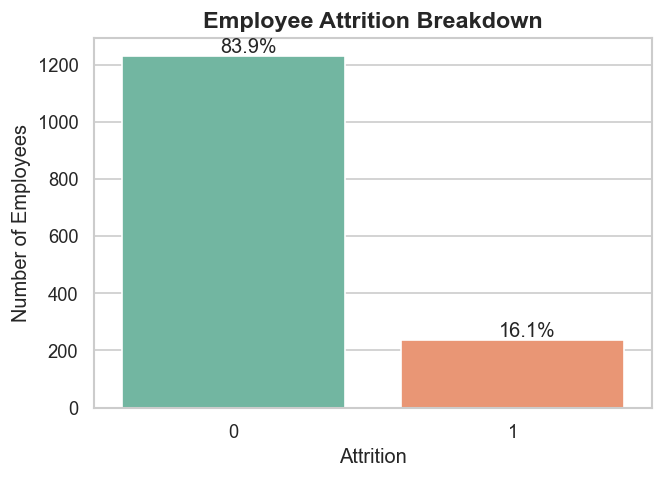

In [18]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title("Employee Attrition Breakdown", fontsize=14, fontweight='bold')
plt.ylabel("Number of Employees")
plt.xlabel("Attrition")

# Add percentages on top of bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 10
    ax.annotate(percentage, (x, y), size=12)

plt.show()

> **Insight**: We have roughly a 16% attrition rate. While this may seem standard for some industries, the cost of replacing 16% of the workforce annually is massive.
> **Solution**: Our goal is to use targeted interventions to reduce this to <10%.

### 2. Income vs. Age Impact on Attrition

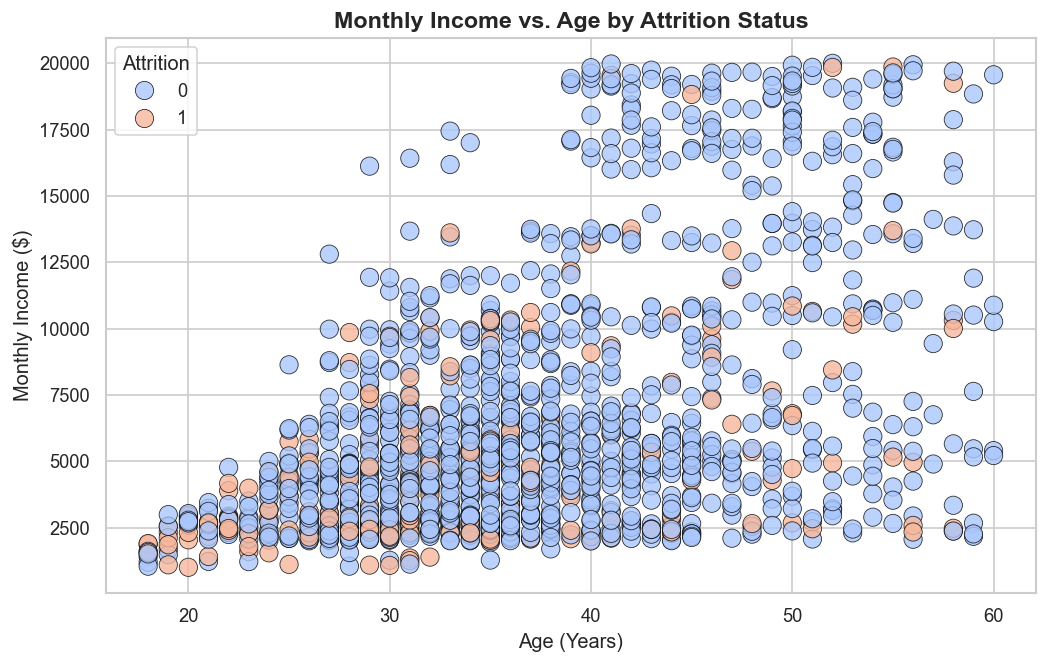

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='MonthlyIncome', hue='Attrition', data=df, alpha=0.8, s=120, edgecolor='black', linewidth=0.5, palette='coolwarm')
plt.title("Monthly Income vs. Age by Attrition Status", fontsize=14, fontweight='bold')
plt.ylabel("Monthly Income ($)")
plt.xlabel("Age (Years)")
plt.show()

> **Insight**: Attrition is densely clustered among younger employees (under 30) making lower monthly incomes (under $5,000). Older, higher-paid employees rarely leave.
> **Solution**: Implement clear career progression pathways, mentorship programs, and review entry-level compensation packages to retain young talent.

### 3. The Overtime Problem

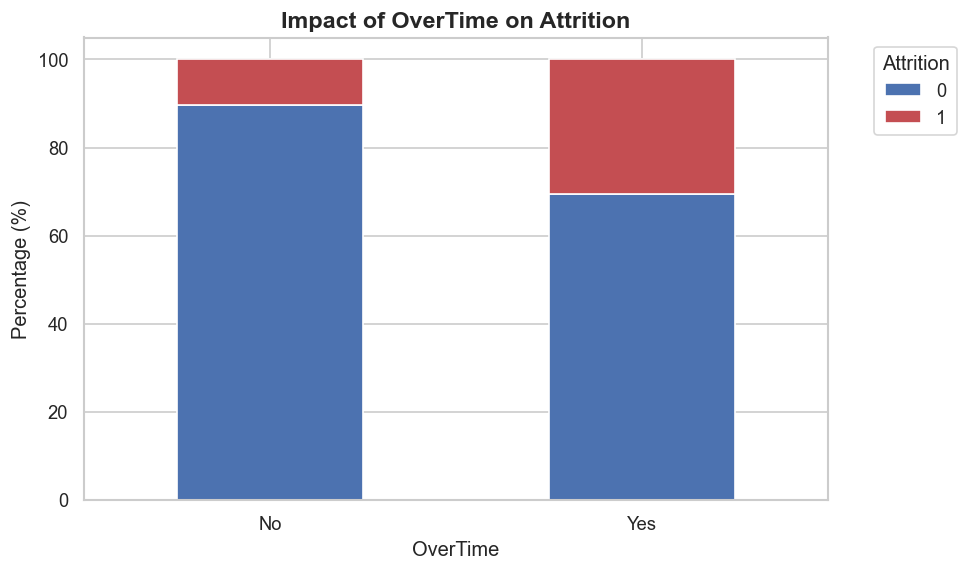

In [20]:
ot_attr = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
ax = ot_attr.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#4C72B0', '#C44E52'])
plt.title('Impact of OverTime on Attrition', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

> **Insight**: Employees working overtime show significantly higher attrition compared to those who do not.
> **Solution**: Monitor overtime hours closely. Hire temporary staff during peak seasons to prevent burnout and ensure a healthy work-life balance.

### 4. Departmental Risk Assessment

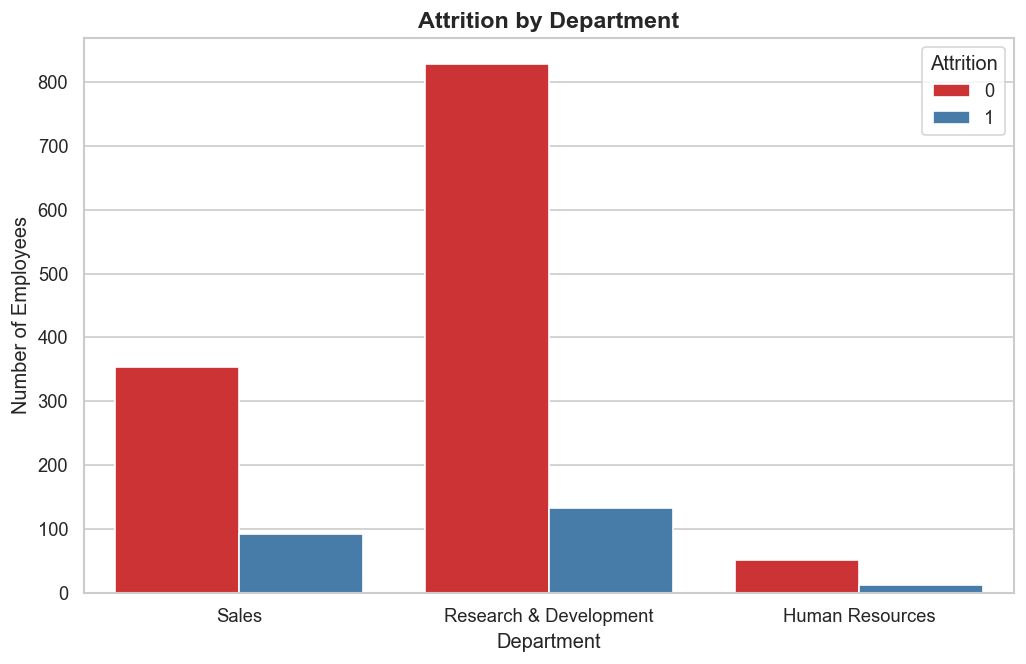

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Department', hue='Attrition', data=df, palette='Set1')
plt.title('Attrition by Department', fontsize=14, fontweight='bold')
plt.ylabel('Number of Employees')
plt.show()

> **Insight**: The Sales department exhibits a disproportionately high turnover rate.
> **Solution**: Conduct targeted stay-interviews within the Sales team to address specific job pressures, quota structures, and commission plans.

---
## 🤖 Machine Learning: Random Forest Predictive Model

We will upgrade from a basic Logistic Regression to a **Random Forest Classifier**. Random Forests handle non-linear relationships well and provide excellent feature importance scores.

In [22]:
# Prepare Data
df_ml = df.copy()

# Robustly handle Attrition column
if 'Attrition_Binary' not in df_ml.columns:
    if 'Attrition' in df_ml.columns:
        if df_ml['Attrition'].dtype == 'O':
            df_ml['Attrition_Binary'] = df_ml['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
        else:
            df_ml['Attrition_Binary'] = df_ml['Attrition']

if 'Attrition' in df_ml.columns:
    df_ml.drop('Attrition', axis=1, inplace=True)

# One-hot encode categorical variables
df_ml = pd.get_dummies(df_ml, drop_first=True)

X = df_ml.drop('Attrition_Binary', axis=1)
y = df_ml['Attrition_Binary']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 87.23%
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       320
           1       0.57      0.08      0.15        48

    accuracy                           0.87       368
   macro avg       0.72      0.54      0.54       368
weighted avg       0.84      0.87      0.83       368



### Feature Importance: Why are they leaving?
This is the most critical graph for HR. It tells us *exactly* which variables the model relies on to predict if someone will quit.

C:\Users\mantu\AppData\Local\Temp\ipykernel_21008\3434600400.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


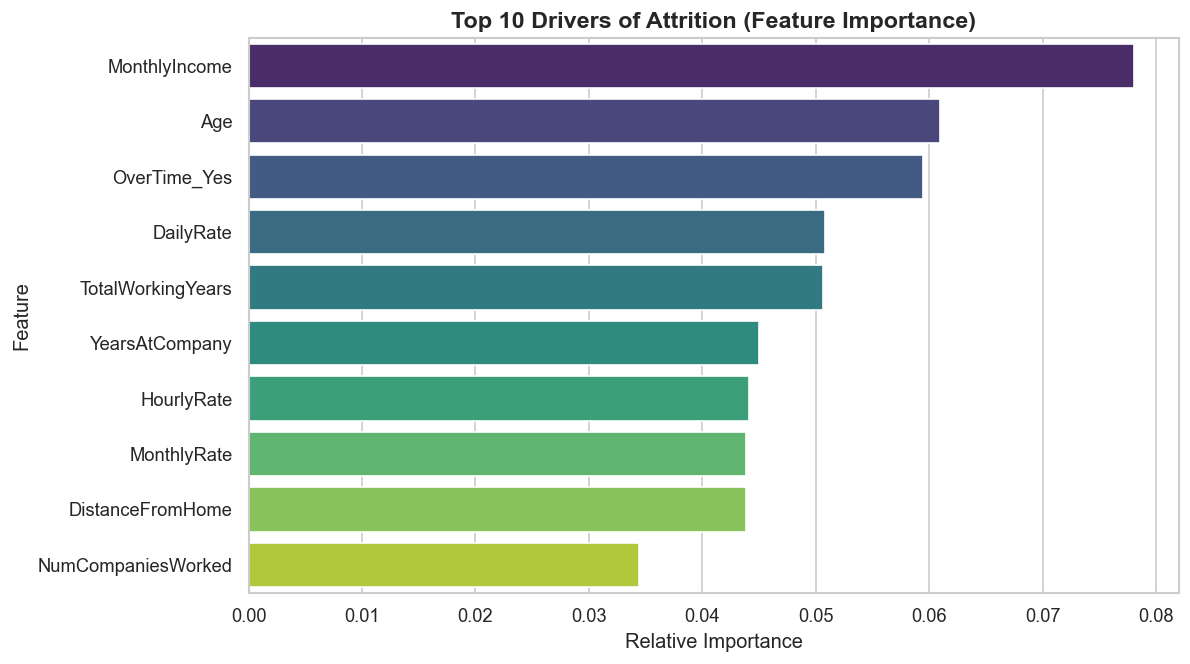

In [23]:
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title("Top 10 Drivers of Attrition (Feature Importance)", fontsize=14, fontweight='bold')
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.show()

> **Final Action Plan**:
> - Focus on the **Top Drivers** listed above. For example, if Monthly Income and Age are at the top, retention strategies must heavily lean on compensation adjustments for younger demographics.
> - By applying this model to current employees, HR can flag individuals with a high probability of leaving and intervene proactively.